<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/capstone_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bivariate Analysis: Income across various features

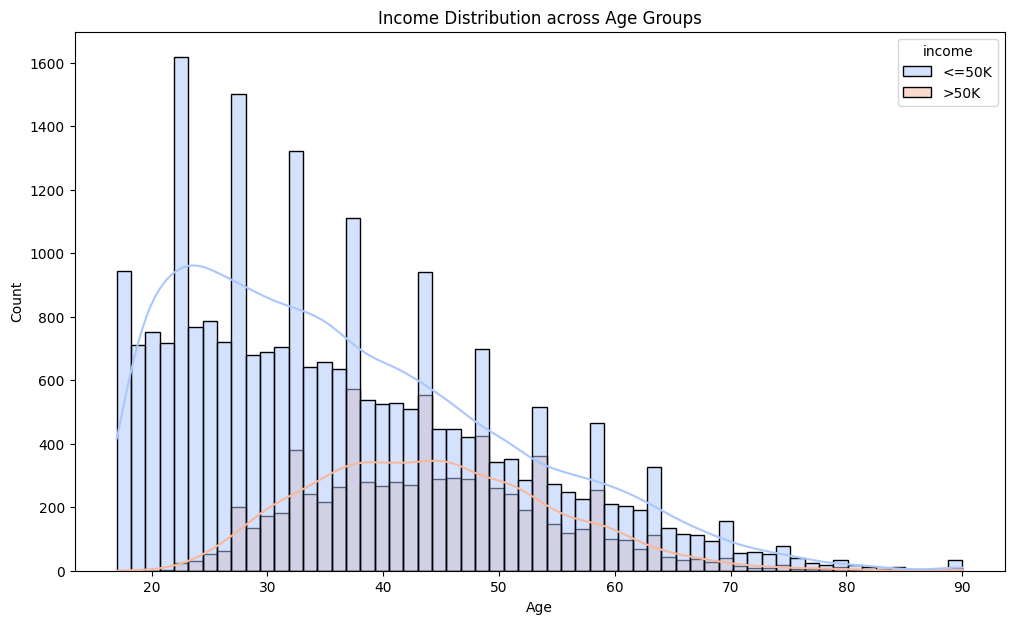

In [9]:
# Bivariate Analysis: Income vs Age
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age', hue='income', kde=True, palette='coolwarm')
plt.title('Income Distribution across Age Groups')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

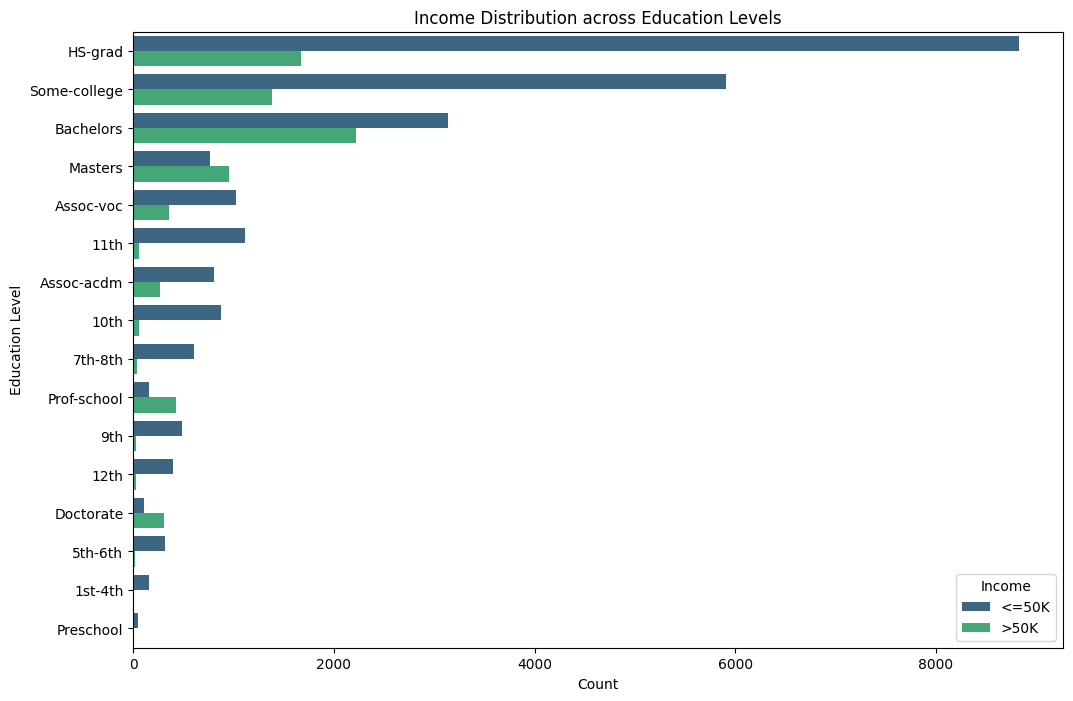

In [10]:
# Bivariate Analysis: Income vs Education
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='education', hue='income', order=df['education'].value_counts().index, palette='viridis')
plt.title('Income Distribution across Education Levels')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Income')
plt.show()

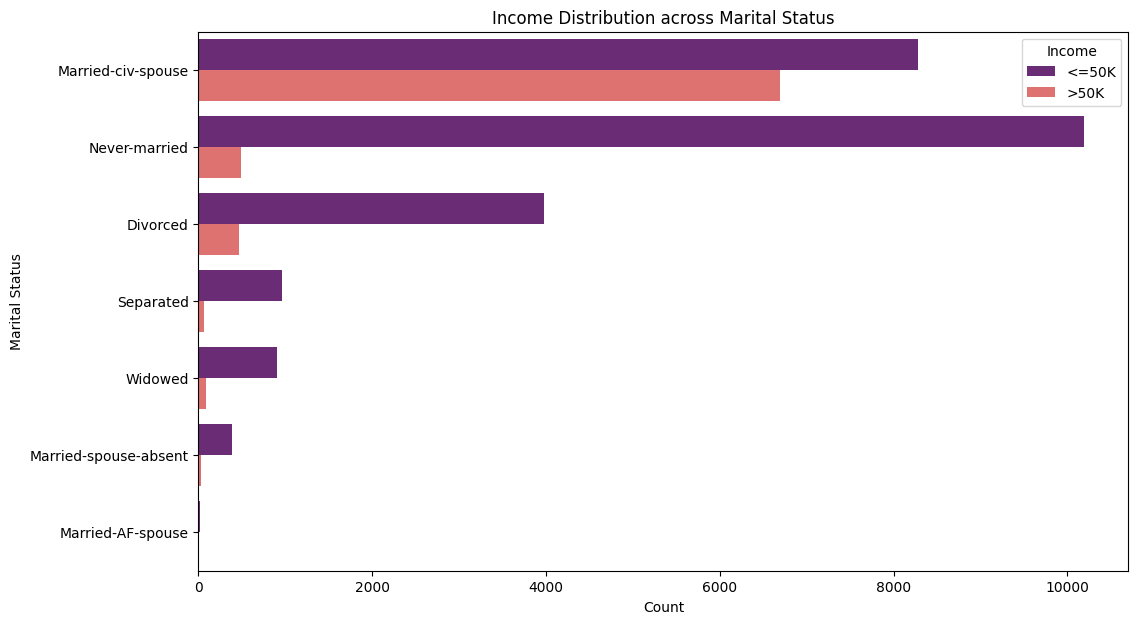

In [11]:
# Bivariate Analysis: Income vs Marital Status
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='marital.status', hue='income', order=df['marital.status'].value_counts().index, palette='magma')
plt.title('Income Distribution across Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.show()

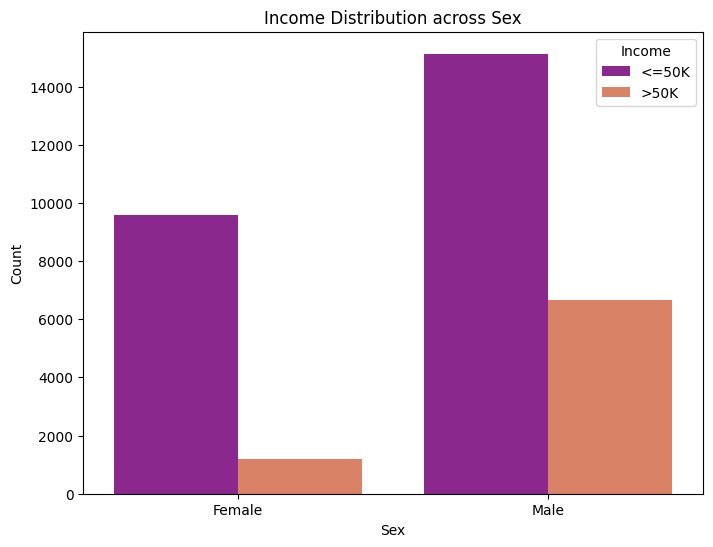

In [12]:
# Bivariate Analysis: Income vs Sex
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sex', hue='income', palette='plasma')
plt.title('Income Distribution across Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Income')
plt.show()

### Correlation Analysis

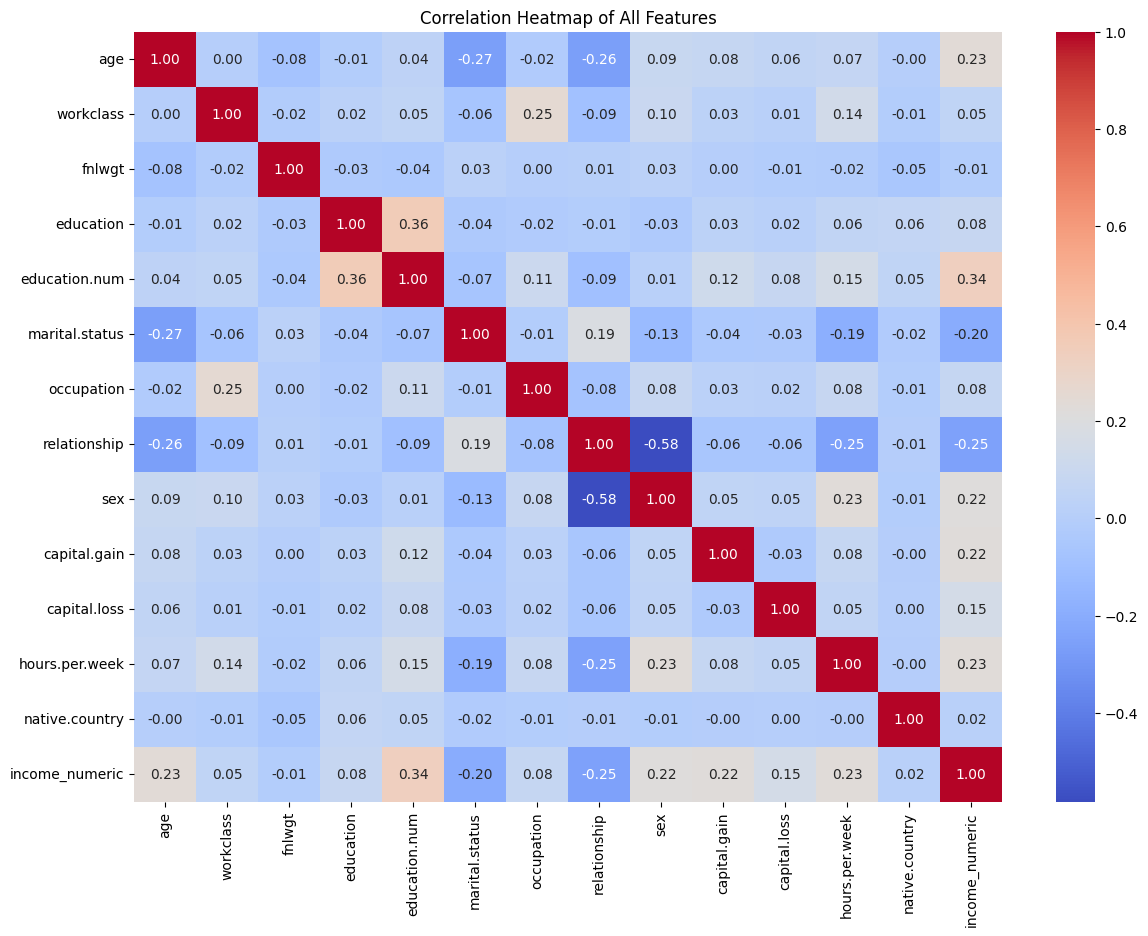


Correlation with Income:


,income_numeric
income_numeric,1.000000
education.num,0.335154
age,0.234037
hours.per.week,0.229689
capital.gain,0.223329
sex,0.215980
capital.loss,0.150526
education,0.079317
occupation,0.075468
workclass,0.051604


In [13]:
# Create a copy of the DataFrame for correlation analysis to avoid modifying the original df for now
df_corr = df.copy()

# Convert 'income' to numerical (0 for <=50K, 1 for >50K)
df_corr['income_numeric'] = df_corr['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Label encode other categorical columns for correlation calculation
for column in df_corr.select_dtypes(include='object').columns:
    if column != 'income': # Exclude the original income column
        df_corr[column] = df_corr[column].astype('category').cat.codes

# Drop original 'income' column as we have 'income_numeric'
df_corr = df_corr.drop('income', axis=1)

# Handle missing values by dropping rows for correlation calculation
df_corr_cleaned = df_corr.dropna()

# Calculate the correlation matrix
correlation_matrix = df_corr_cleaned.corr()

# Draw the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features')
plt.show()

# Find columns highly correlated with 'income_numeric'
income_correlations = correlation_matrix['income_numeric'].sort_values(ascending=False)
print("\nCorrelation with Income:")
display(income_correlations)

### Data Preparation for Modeling

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Impute missing values for categorical columns using the mode
for column in ['workclass', 'occupation', 'native.country']:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Verify that there are no more null values
print("Null values after imputation:")
display(df.isnull().sum())

# Label encode all categorical columns
for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

print("\nDataFrame after Label Encoding:")
display(df.head())

# Prepare independent variables X and dependent variable Y
X = df.drop('income', axis=1)
y = df['income']

# Perform a train test split in the ratio 80:20 and random_state 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fix the imbalance in the dataset using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_scaled, y_train)

print("\nOriginal training target distribution:")
display(y_train.value_counts())
print("\nResampled training target distribution:")
display(y_resampled.value_counts())

Null values after imputation:


/tmp/ipykernel_2636/838365603.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
sex,0
capital.gain,0



DataFrame after Label Encoding:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,0,0,3900,40,38,0



X_train shape: (26048, 13)
X_test shape: (6513, 13)
y_train shape: (26048,)
y_test shape: (6513,)

Original training target distribution:


,count
income,
0,19775
1,6273



Resampled training target distribution:


,count
income,
1,19775
0,19775


### Data Modeling and Evaluation

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN Classifier': KNeighborsClassifier(),
    'SVM Classifier': SVC(random_state=42),
    'Naive Bayes Classifier': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': accuracy, 'F1 Score': f1})
    print(f"{name} - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}\n")

# Display results in a DataFrame
results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
display(results_df.sort_values(by='F1 Score', ascending=False))

# Identify the best model based on F1 Score
best_model_f1 = results_df.loc[results_df['F1 Score'].idxmax()]
print(f"\nBest Model based on F1 Score: {best_model_f1['Model']} (Accuracy: {best_model_f1['Accuracy']:.4f}, F1 Score: {best_model_f1['F1 Score']:.4f})")

# Identify the best model based on Accuracy
best_model_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model based on Accuracy: {best_model_accuracy['Model']} (Accuracy: {best_model_accuracy['Accuracy']:.4f}, F1 Score: {best_model_accuracy['F1 Score']:.4f})")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.7749, F1 Score: 0.6220

Training KNN Classifier...
KNN Classifier - Accuracy: 0.7772, F1 Score: 0.6267

Training SVM Classifier...
SVM Classifier - Accuracy: 0.7924, F1 Score: 0.6630

Training Naive Bayes Classifier...
Naive Bayes Classifier - Accuracy: 0.8138, F1 Score: 0.5311

Training Decision Tree Classifier...
Decision Tree Classifier - Accuracy: 0.8105, F1 Score: 0.6022

Training Random Forest Classifier...
Random Forest Classifier - Accuracy: 0.8485, F1 Score: 0.6854


Model Evaluation Results:


,Model,Accuracy,F1 Score
5,Random Forest Classifier,0.848457,0.685368
2,SVM Classifier,0.792415,0.663011
1,KNN Classifier,0.777215,0.626704
0,Logistic Regression,0.774912,0.621970
4,Decision Tree Classifier,0.810533,0.602192
3,Naive Bayes Classifier,0.813757,0.531117



Best Model based on F1 Score: Random Forest Classifier (Accuracy: 0.8485, F1 Score: 0.6854)

Best Model based on Accuracy: Random Forest Classifier (Accuracy: 0.8485, F1 Score: 0.6854)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/adultcensusincome.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


In [2]:
# Check for null values
print("\nNull values before handling:")
display(df.isnull().sum())

# Check for '?' values in all columns and replace with NaN
for column in df.columns:
    if (df[column] == '?').any():
        df[column] = df[column].replace('?', np.nan)

print("\nNull values after replacing '?' with NaN:")
display(df.isnull().sum())

# Display the percentage of missing values per column
missing_percentage = df.isnull().sum() / len(df) * 100
print("\nPercentage of missing values per column:")
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


Null values before handling:


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
sex,0
capital.gain,0



Null values after replacing '?' with NaN:


,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
sex,0
capital.gain,0



Percentage of missing values per column:


,0
occupation,5.660146
workclass,5.638647
native.country,1.790486


In [3]:
# Check distribution of the target variable 'income'
print("\nDistribution of 'income' variable:")
display(df['income'].value_counts())

print("\nNormalized distribution of 'income' variable:")
display(df['income'].value_counts(normalize=True))


Distribution of 'income' variable:


,count
income,
<=50K,24720
>50K,7841



Normalized distribution of 'income' variable:


,proportion
income,
<=50K,0.75919
>50K,0.24081


From the normalized distribution, we can see that the dataset is imbalanced, with a significantly higher number of records for income `<=50K` compared to `>50K`.

/tmp/ipykernel_2636/3023544199.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='viridis')


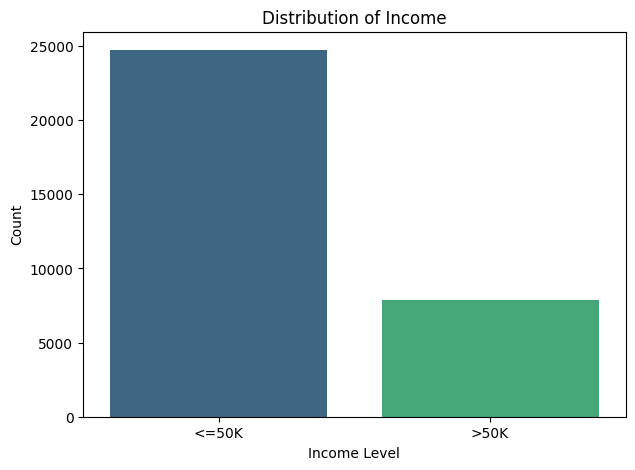

In [4]:
# Univariate Analysis: Barplot for income
plt.figure(figsize=(7, 5))
sns.countplot(x='income', data=df, palette='viridis')
plt.title('Distribution of Income')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

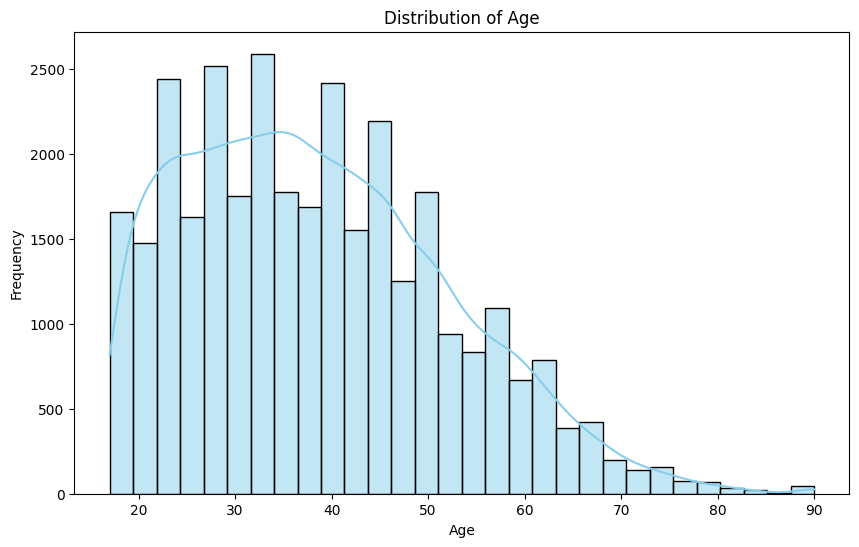

In [5]:
# Univariate Analysis: Distribution plot for age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2636/3758206689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='education', data=df, order=df['education'].value_counts().index, palette='magma')


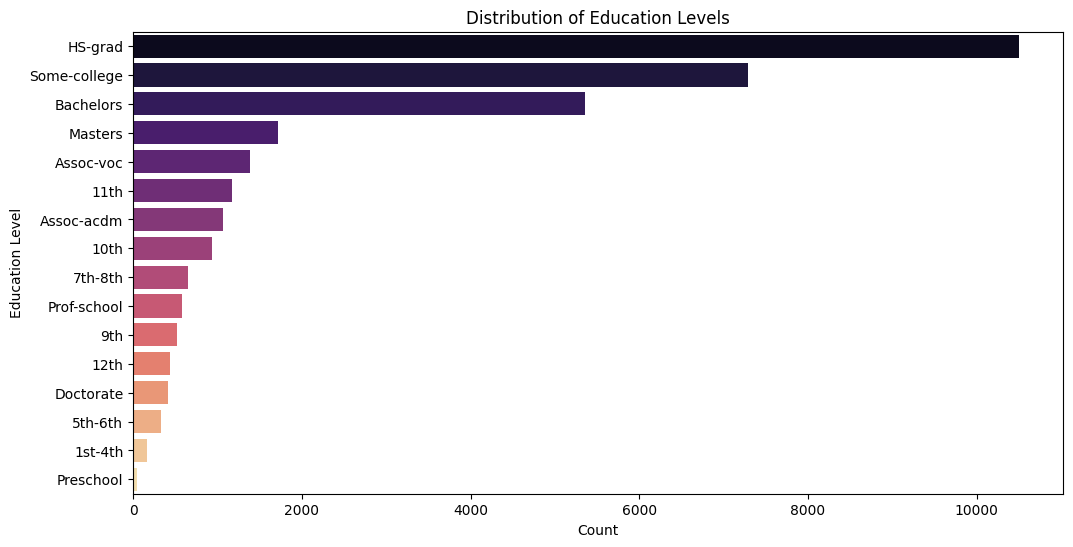

In [6]:
# Univariate Analysis: Barplot for education
plt.figure(figsize=(12, 6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index, palette='magma')
plt.title('Distribution of Education Levels')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.show()

/tmp/ipykernel_2636/3342274462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education.num', data=df, palette='cividis')


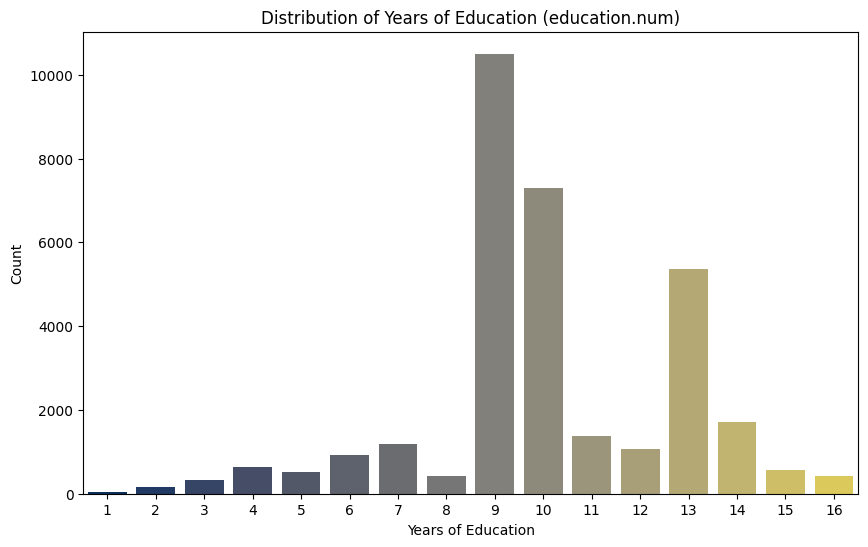

In [7]:
# Univariate Analysis: Barplot for Years of Education (education.num)
plt.figure(figsize=(10, 6))
sns.countplot(x='education.num', data=df, palette='cividis')
plt.title('Distribution of Years of Education (education.num)')
plt.xlabel('Years of Education')
plt.ylabel('Count')
plt.show()

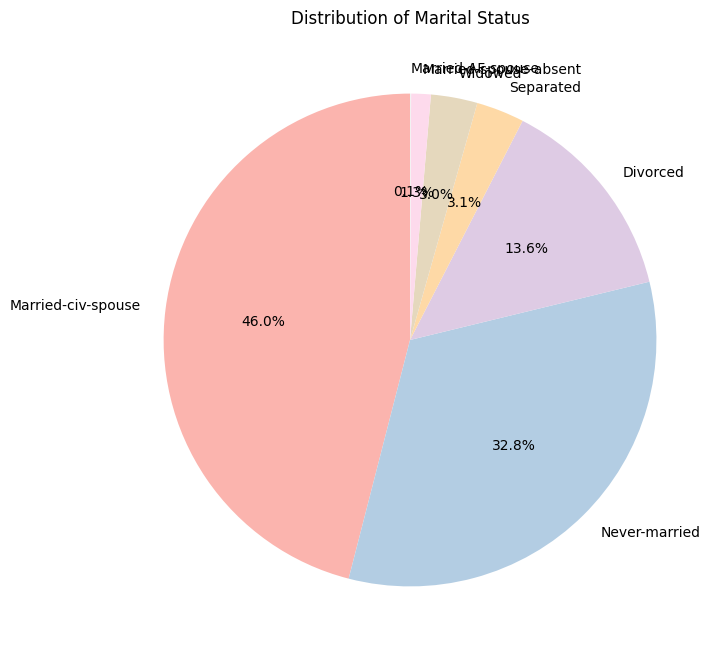

In [8]:
# Univariate Analysis: Pie chart for Marital status
plt.figure(figsize=(10, 8))
df['marital.status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Distribution of Marital Status')
plt.ylabel('') # Hide the default 'marital.status' label on the y-axis
plt.show()

### Bivariate Analysis: Income across various features

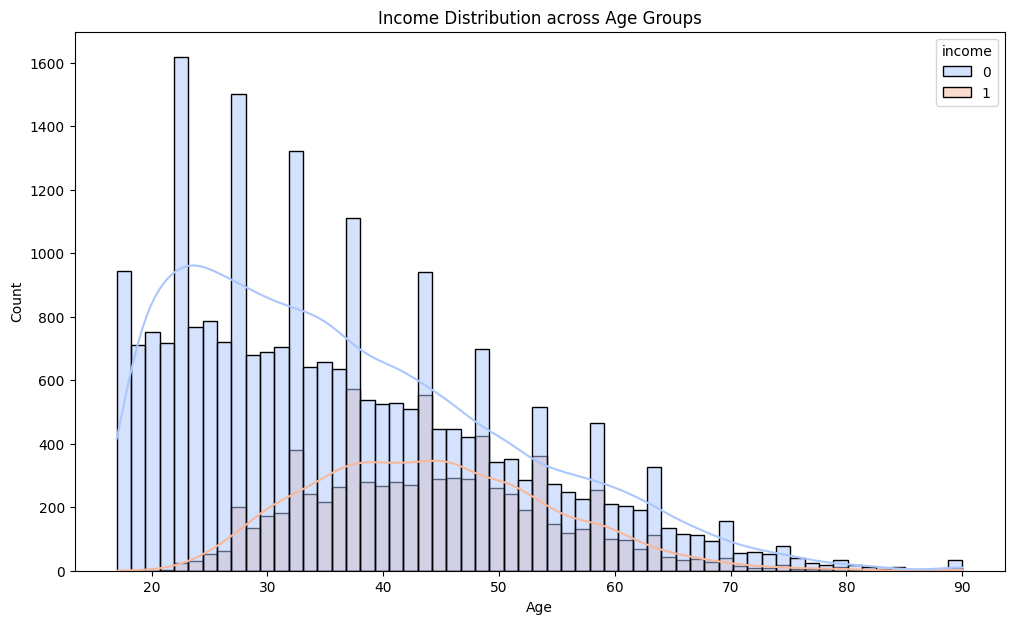

In [16]:
# Bivariate Analysis: Income vs Age
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age', hue='income', kde=True, palette='coolwarm')
plt.title('Income Distribution across Age Groups')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

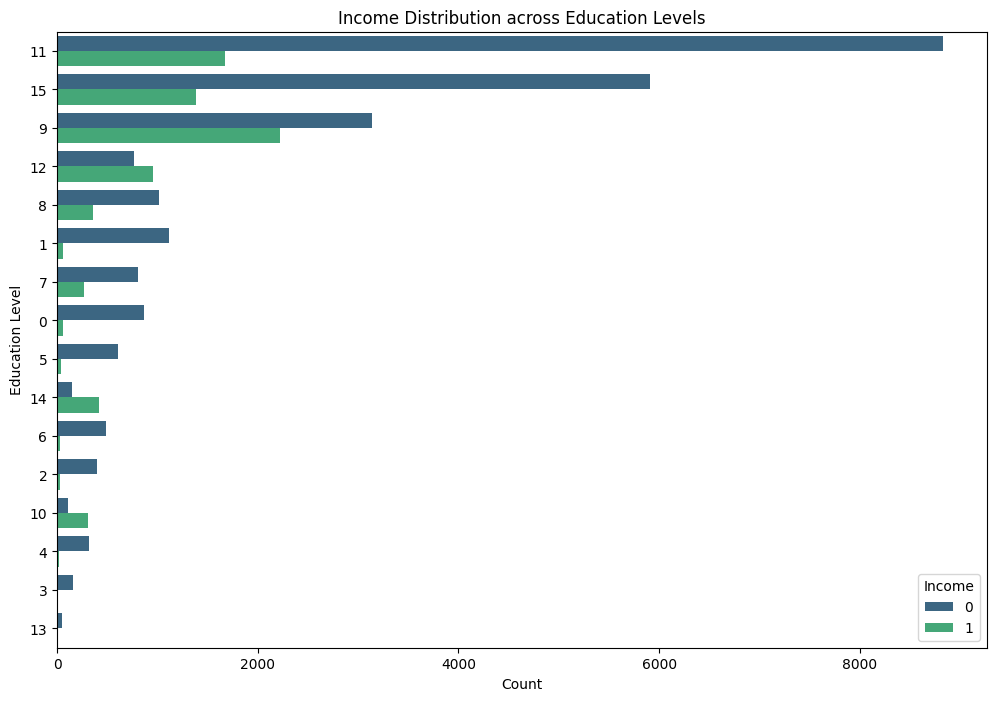

In [17]:
# Bivariate Analysis: Income vs Education
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='education', hue='income', order=df['education'].value_counts().index, palette='viridis')
plt.title('Income Distribution across Education Levels')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Income')
plt.show()

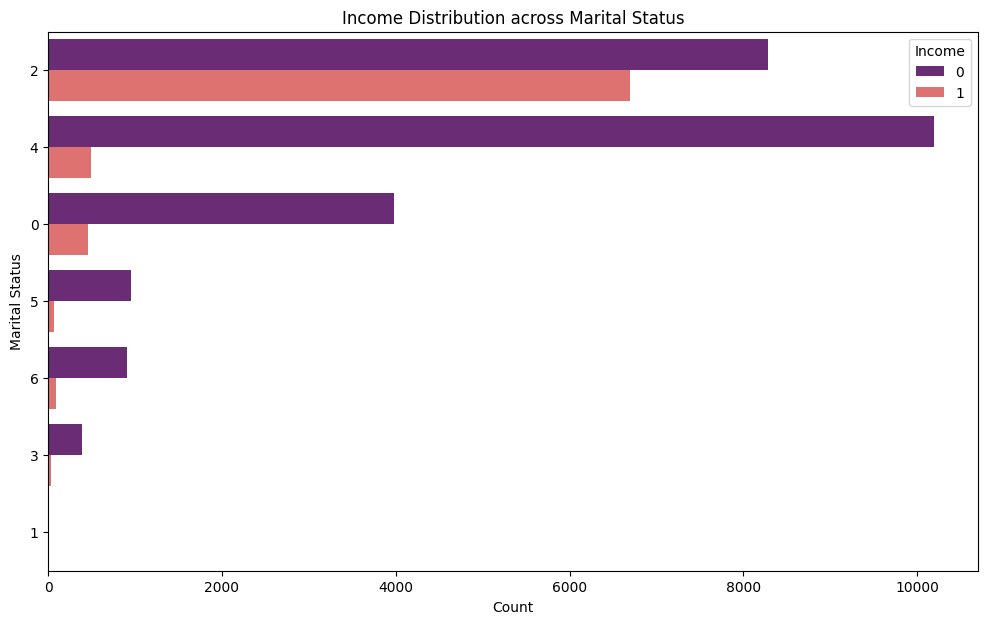

In [18]:
# Bivariate Analysis: Income vs Marital Status
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='marital.status', hue='income', order=df['marital.status'].value_counts().index, palette='magma')
plt.title('Income Distribution across Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.show()

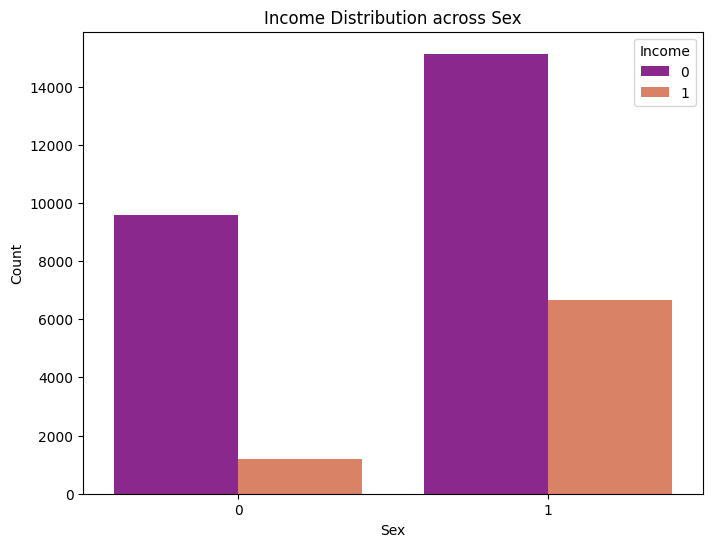

In [19]:
# Bivariate Analysis: Income vs Sex
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sex', hue='income', palette='plasma')
plt.title('Income Distribution across Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Income')
plt.show()

### Correlation Analysis

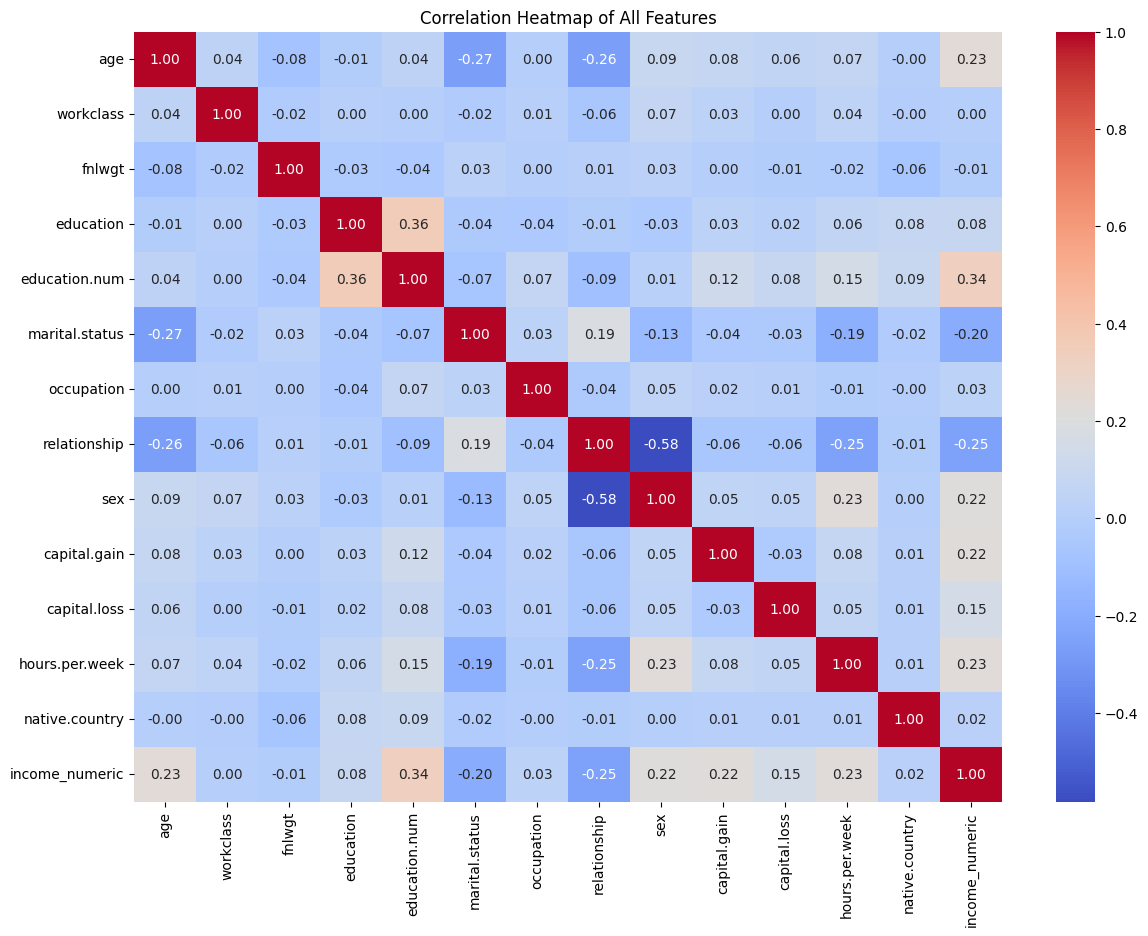


Correlation with Income:


,income_numeric
income_numeric,1.000000
education.num,0.335154
age,0.234037
hours.per.week,0.229689
capital.gain,0.223329
sex,0.215980
capital.loss,0.150526
education,0.079317
occupation,0.034625
native.country,0.023058


In [23]:
# Create a copy of the DataFrame for correlation analysis
df_corr = df.copy()

# Since 'df' has already been label encoded, 'income' column contains 0s and 1s directly.
# So, we can directly use the 'income' column for 'income_numeric'.
df_corr['income_numeric'] = df_corr['income']

# The original 'income' column can be dropped from df_corr to avoid redundancy
df_corr = df_corr.drop('income', axis=1)

# Handle missing values by dropping rows for correlation calculation (if any remained from initial '?' handling)
df_corr_cleaned = df_corr.dropna()

# Calculate the correlation matrix
correlation_matrix = df_corr_cleaned.corr()

# Draw the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features')
plt.show()

# Find columns highly correlated with 'income_numeric'
income_correlations = correlation_matrix['income_numeric'].sort_values(ascending=False)
print("\nCorrelation with Income:")
display(income_correlations)

### Data Preparation for Modeling

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Impute missing values for categorical columns using the mode
for column in ['workclass', 'occupation', 'native.country']:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Verify that there are no more null values
print("Null values after imputation:")
display(df.isnull().sum())

# Label encode all categorical columns
for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

print("\nDataFrame after Label Encoding:")
display(df.head())

# Prepare independent variables X and dependent variable Y
X = df.drop('income', axis=1)
y = df['income']

# Perform a train test split in the ratio 80:20 and random_state 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fix the imbalance in the dataset using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_scaled, y_train)

print("\nOriginal training target distribution:")
display(y_train.value_counts())
print("\nResampled training target distribution:")
display(y_resampled.value_counts())

Null values after imputation:


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
sex,0
capital.gain,0



DataFrame after Label Encoding:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,0,0,3900,40,38,0



X_train shape: (26048, 13)
X_test shape: (6513, 13)
y_train shape: (26048,)
y_test shape: (6513,)

Original training target distribution:


,count
income,
0,19775
1,6273



Resampled training target distribution:


,count
income,
1,19775
0,19775


### Data Modeling and Evaluation

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN Classifier': KNeighborsClassifier(),
    'SVM Classifier': SVC(random_state=42),
    'Naive Bayes Classifier': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': accuracy, 'F1 Score': f1})
    print(f"{name} - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}\n")

# Display results in a DataFrame
results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
display(results_df.sort_values(by='F1 Score', ascending=False))

# Identify the best model based on F1 Score
best_model_f1 = results_df.loc[results_df['F1 Score'].idxmax()]
print(f"\nBest Model based on F1 Score: {best_model_f1['Model']} (Accuracy: {best_model_f1['Accuracy']:.4f}, F1 Score: {best_model_f1['F1 Score']:.4f})")

# Identify the best model based on Accuracy
best_model_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model based on Accuracy: {best_model_accuracy['Model']} (Accuracy: {best_model_accuracy['Accuracy']:.4f}, F1 Score: {best_model_accuracy['F1 Score']:.4f})")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.7749, F1 Score: 0.6220

Training KNN Classifier...
KNN Classifier - Accuracy: 0.7772, F1 Score: 0.6267

Training SVM Classifier...
SVM Classifier - Accuracy: 0.7924, F1 Score: 0.6630

Training Naive Bayes Classifier...
Naive Bayes Classifier - Accuracy: 0.8138, F1 Score: 0.5311

Training Decision Tree Classifier...
Decision Tree Classifier - Accuracy: 0.8105, F1 Score: 0.6022

Training Random Forest Classifier...
Random Forest Classifier - Accuracy: 0.8485, F1 Score: 0.6854


Model Evaluation Results:


,Model,Accuracy,F1 Score
5,Random Forest Classifier,0.848457,0.685368
2,SVM Classifier,0.792415,0.663011
1,KNN Classifier,0.777215,0.626704
0,Logistic Regression,0.774912,0.621970
4,Decision Tree Classifier,0.810533,0.602192
3,Naive Bayes Classifier,0.813757,0.531117



Best Model based on F1 Score: Random Forest Classifier (Accuracy: 0.8485, F1 Score: 0.6854)

Best Model based on Accuracy: Random Forest Classifier (Accuracy: 0.8485, F1 Score: 0.6854)
